<a href="https://colab.research.google.com/github/islam3ouf/Linear-Algebra-Visualization-With-Python/blob/main/01-Vector-Visualization/notebooks/animated_vector_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving animation...
Animation saved as 'vector_operations.gif'.


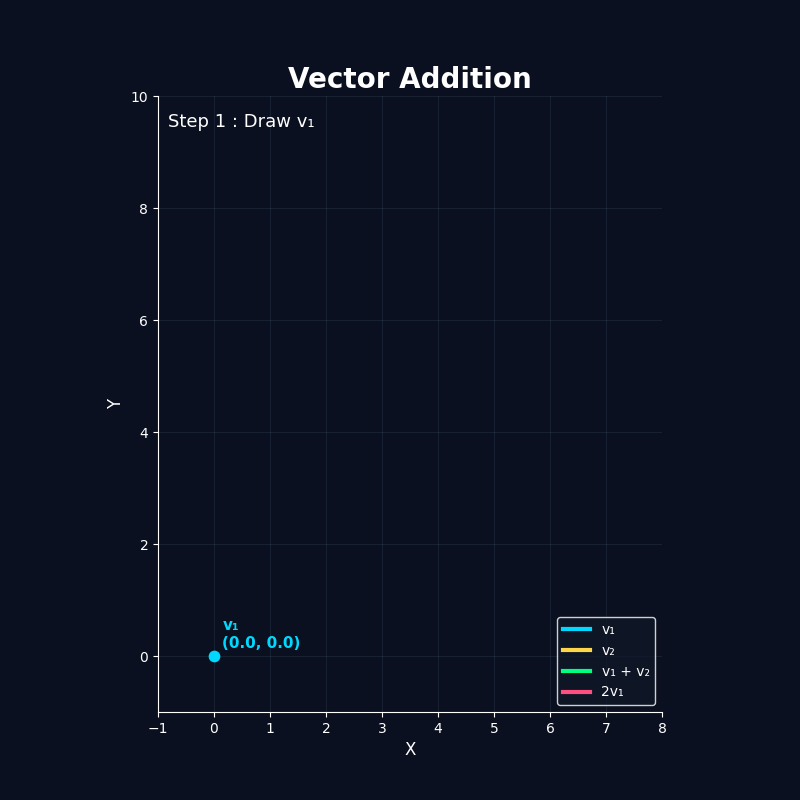

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D
from IPython.display import Image, display


# VECTOR DATA


V1 = np.array([2, 3])
V2 = np.array([3, 1])

VECTOR_SUM = V1 + V2
DOUBLE_V1 = 2 * V1


# COLORS


BACKGROUND_COLOR = "#0B1020"
GRID_COLOR = "#334155"

VECTOR1_COLOR = "#00D9FF"
VECTOR2_COLOR = "#FFD54A"
SUM_COLOR = "#00FF7F"
SCALE_COLOR = "#FF4F81"


# ANIMATION TIMELINE


DRAW_V1_END = 40
DRAW_V2_END = 80
TAIL_TO_HEAD_END = 120
SUM_END = 160
PAUSE_END = 200
FADE_END = 220
SCALAR_START = 260
SCALAR_GROW_END = 320

TOTAL_FRAMES = 360


# FIGURE


fig, ax = plt.subplots(
    figsize=(8, 8),
    facecolor=BACKGROUND_COLOR
)

ax.set_facecolor(BACKGROUND_COLOR)


# LEGEND (Create Once)


LEGEND_HANDLES = [
    Line2D([0], [0], color=VECTOR1_COLOR, lw=3, label="v₁"),
    Line2D([0], [0], color=VECTOR2_COLOR, lw=3, label="v₂"),
    Line2D([0], [0], color=SUM_COLOR, lw=3, label="v₁ + v₂"),
    Line2D([0], [0], color=SCALE_COLOR, lw=3, label="2v₁"),
]


# AXES STYLE


def style_axes(ax):
    """Apply the visual style to the coordinate system."""

    ax.set_xlim(-1, 8)
    ax.set_ylim(-1, 10)
    ax.set_aspect("equal")

    ax.grid(
        color=GRID_COLOR,
        linewidth=0.8,
        alpha=0.35,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("white")
    ax.spines["bottom"].set_color("white")

    ax.tick_params(colors="white")

    ax.set_xlabel("X", fontsize=12, color="white")
    ax.set_ylabel("Y", fontsize=12, color="white")



# DRAW VECTOR


def draw_vector(
    ax,
    vector,
    color,
    label,
    alpha=1.0,
    integer_coordinates=False,
):
    """Draw a vector starting from the origin."""

    ax.arrow(
        0,
        0,
        vector[0],
        vector[1],
        color=color,
        linewidth=3.5,
        head_width=0.20,
        head_length=0.30,
        length_includes_head=True,
        alpha=alpha,
    )

    ax.scatter(
        vector[0],
        vector[1],
        s=55,
        color=color,
        alpha=alpha,
        zorder=5,
    )

    if integer_coordinates:
        coordinates = (
            f"({int(round(vector[0]))}, "
            f"{int(round(vector[1]))})"
        )
    else:
        coordinates = (
            f"({vector[0]:.1f}, "
            f"{vector[1]:.1f})"
        )

    ax.text(
        vector[0] + 0.15,
        vector[1] + 0.15,
        f"{label}\n{coordinates}",
        fontsize=11,
        fontweight="bold",
        color=color,
    )



# TAIL-TO-HEAD RULE


def draw_tail_to_head(ax):
    """Illustrate the tail-to-head vector addition rule."""

    ax.arrow(
        V1[0],
        V1[1],
        V2[0],
        V2[1],
        linestyle="--",
        linewidth=2,
        color=VECTOR2_COLOR,
        alpha=0.55,
        head_width=0.15,
        length_includes_head=True,
    )



# COMMON LAYOUT


def setup_frame():
    """Prepare the current animation frame."""

    ax.clear()
    ax.set_facecolor(BACKGROUND_COLOR)

    style_axes(ax)

    ax.legend(
        handles=LEGEND_HANDLES,
        loc="lower right",
        facecolor="#101828",
        edgecolor="white",
        fontsize=10,
        labelcolor="white",
    )


# ANIMATION


def animate(frame):
    """Update a single animation frame."""

    setup_frame()


    # Step 1 : Draw v1


    if frame < DRAW_V1_END:

        progress = frame / DRAW_V1_END

        draw_vector(
            ax,
            V1 * progress,
            VECTOR1_COLOR,
            "v₁",
        )

        ax.set_title(
            "Vector Addition",
            fontsize=20,
            color="white",
            weight="bold",
        )

        ax.text(
            0.02,
            0.95,
            "Step 1 : Draw v₁",
            transform=ax.transAxes,
            fontsize=13,
            color="white",
        )


    # Step 2 : Draw v2


    elif frame < DRAW_V2_END:

        draw_vector(
            ax,
            V1,
            VECTOR1_COLOR,
            "v₁",
            integer_coordinates=True,
        )

        progress = (
            frame - DRAW_V1_END
        ) / (
            DRAW_V2_END - DRAW_V1_END
        )

        draw_vector(
            ax,
            V2 * progress,
            VECTOR2_COLOR,
            "v₂",
        )

        ax.set_title(
            "Vector Addition",
            fontsize=20,
            color="white",
            weight="bold",
        )

        ax.text(
            0.02,
            0.95,
            "Step 2 : Draw v₂",
            transform=ax.transAxes,
            fontsize=13,
            color="white",
        )


    # Step 3 : Tail-to-Head Rule


    elif frame < TAIL_TO_HEAD_END:

        draw_vector(
            ax,
            V1,
            VECTOR1_COLOR,
            "v₁",
            integer_coordinates=True,
        )

        draw_vector(
            ax,
            V2,
            VECTOR2_COLOR,
            "v₂",
            integer_coordinates=True,
        )

        draw_tail_to_head(ax)

        ax.set_title(
            "Tail-to-Head Rule",
            fontsize=20,
            color="white",
            weight="bold",
        )

        ax.text(
            0.02,
            0.95,
            "Move v₂ to the head of v₁",
            transform=ax.transAxes,
            fontsize=13,
            color="white",
        )


    # Step 4 : Draw Sum Vector


    elif frame < SUM_END:

        draw_vector(
            ax,
            V1,
            VECTOR1_COLOR,
            "v₁",
            integer_coordinates=True,
        )

        draw_vector(
            ax,
            V2,
            VECTOR2_COLOR,
            "v₂",
            integer_coordinates=True,
        )

        draw_tail_to_head(ax)

        progress = (
            frame - TAIL_TO_HEAD_END
        ) / (
            SUM_END - TAIL_TO_HEAD_END
        )

        draw_vector(
            ax,
            VECTOR_SUM * progress,
            SUM_COLOR,
            "v₁ + v₂",
        )

        ax.set_title(
            "Vector Addition",
            fontsize=20,
            color="white",
            weight="bold",
        )

        ax.text(
            0.02,
            0.95,
            "v₁ + v₂ = (5, 4)",
            transform=ax.transAxes,
            fontsize=13,
            color="white",
        )


    # Step 5 : Pause


    elif frame < PAUSE_END:

        draw_vector(
            ax,
            V1,
            VECTOR1_COLOR,
            "v₁",
            integer_coordinates=True,
        )

        draw_vector(
            ax,
            V2,
            VECTOR2_COLOR,
            "v₂",
            integer_coordinates=True,
        )

        draw_vector(
            ax,
            VECTOR_SUM,
            SUM_COLOR,
            "v₁ + v₂",
            integer_coordinates=True,
        )

        draw_tail_to_head(ax)

        ax.set_title(
            "Vector Addition Complete",
            fontsize=20,
            color="white",
            weight="bold",
        )


    # Step 6 : Fade Out


    elif frame < FADE_END:

        alpha = 1 - (
            frame - PAUSE_END
        ) / (
            FADE_END - PAUSE_END
        )

        draw_vector(
            ax,
            V1,
            VECTOR1_COLOR,
            "v₁",
            alpha=alpha,
            integer_coordinates=True,
        )

        draw_vector(
            ax,
            V2,
            VECTOR2_COLOR,
            "v₂",
            alpha=alpha,
            integer_coordinates=True,
        )

        draw_vector(
            ax,
            VECTOR_SUM,
            SUM_COLOR,
            "v₁ + v₂",
            alpha=alpha,
            integer_coordinates=True,
        )

        ax.set_title(
            "Transition",
            fontsize=20,
            color="white",
            weight="bold",
        )


    # Step 7 : Scalar Multiplication


    elif frame < SCALAR_START:

        draw_vector(
            ax,
            V1,
            VECTOR1_COLOR,
            "v₁",
            integer_coordinates=True,
        )

        ax.set_title(
            "Scalar Multiplication",
            fontsize=20,
            color="white",
            weight="bold",
        )

        ax.text(
            0.02,
            0.95,
            "Multiply v₁ by 2",
            transform=ax.transAxes,
            fontsize=13,
            color="white",
        )


    # Step 8 : Grow to 2v₁


    elif frame < SCALAR_GROW_END:

        progress = (
            frame - SCALAR_START
        ) / (
            SCALAR_GROW_END - SCALAR_START
        )

        progress = (
            3 * progress**2
            - 2 * progress**3
        )

        current_vector = (
            V1 +
            (DOUBLE_V1 - V1) * progress
        )

        draw_vector(
            ax,
            current_vector,
            SCALE_COLOR,
            "2v₁",
        )

        ax.set_title(
            "Scalar Multiplication",
            fontsize=20,
            color="white",
            weight="bold",
        )

        ax.text(
            0.02,
            0.95,
            "2 × v₁ = (4, 6)",
            transform=ax.transAxes,
            fontsize=13,
            color="white",
        )


    # Step 9 : Final Result


    else:

        draw_vector(
            ax,
            DOUBLE_V1,
            SCALE_COLOR,
            "2v₁",
            integer_coordinates=True,
        )

        ax.set_title(
            "Scalar Multiplication Complete",
            fontsize=20,
            color="white",
            weight="bold",
        )

        ax.text(
            0.02,
            0.95,
            "2 × v₁ = (4, 6)",
            transform=ax.transAxes,
            fontsize=13,
            color="white",
        )



# CREATE & SAVE ANIMATION


def save_animation(filename="vector_operations.gif"):
    """Generate and save the animation."""

    animation = FuncAnimation(
        fig,
        animate,
        frames=TOTAL_FRAMES,
        interval=40,
        repeat=True,
        repeat_delay=1500,
        blit=False,
    )

    print("Saving animation...")

    animation.save(
        filename,
        writer=PillowWriter(fps=25),
    )

    plt.close(fig)

    print(f"Animation saved as '{filename}'.")

    return filename


# MAIN


def main():

    gif_file = save_animation()

    display(Image(filename=gif_file))


if __name__ == "__main__":
    main()